# Modeling using Naϊve Bayes and Random Forest Algorithms

In [73]:
import warnings
# warnings.filterwarnings('ignore')
warnings.filterwarnings('always')

In [74]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import CategoricalNB

In [75]:
%run ../custom/jc-functions.ipynb

## Prepare Dataset

In [76]:
# Import training dataset 
dataset = Path('../dataset')
df = pd.read_csv(dataset/'accidents_clean_train.csv')
df.head()

,Area_accident_occured,Types_of_Junction,Light_conditions,Number_of_vehicles_involved,Number_of_casualties,Cause_of_accident,Day_of_week,Sex_of_driver,Age_band_of_driver,Accident_severity
0,Residential areas,No junction,Daylight,2,2,Moving Backward,Monday,Male,18-30,Slight Injury
1,Office areas,No junction,Daylight,2,2,Overtaking,Monday,Male,31-50,Slight Injury
2,Recreational areas,No junction,Daylight,2,2,Changing lane to the left,Monday,Male,18-30,Serious Injury
3,Office areas,Y Shape,Darkness - lights lit,2,2,Changing lane to the right,Sunday,Male,18-30,Slight Injury
4,Industrial areas,Y Shape,Darkness - lights lit,2,2,Overtaking,Sunday,Male,18-30,Slight Injury


In [77]:
df.shape

(8210, 10)

In [78]:
# Get feature columns
columns = df.columns.tolist()
print(columns)

features = ['Area_accident_occured', 'Types_of_Junction', 'Light_conditions', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Cause_of_accident', 'Day_of_week', 'Sex_of_driver', 'Age_band_of_driver']

target = 'Accident_severity'

['Area_accident_occured', 'Types_of_Junction', 'Light_conditions', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Cause_of_accident', 'Day_of_week', 'Sex_of_driver', 'Age_band_of_driver', 'Accident_severity']


### Training dataset

In [79]:
# Convert to categorical
X = df[features]
X = pd.get_dummies(X, drop_first=True)
X.head()

,Number_of_vehicles_involved,Number_of_casualties,Area_accident_occured_ Recreational areas,Area_accident_occured_ Church areas,Area_accident_occured_ Hospital areas,Area_accident_occured_ Industrial areas,Area_accident_occured_ Outside rural areas,Area_accident_occured_Office areas,Area_accident_occured_Other,Area_accident_occured_Recreational areas,...,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Sex_of_driver_Male,Sex_of_driver_Unknown,Age_band_of_driver_31-50,Age_band_of_driver_Over 51,Age_band_of_driver_Under 18,Age_band_of_driver_Unknown
0,2,2,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,2,2,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
2,2,2,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2,2,False,False,False,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
4,2,2,False,False,False,True,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False


In [80]:
# Create mapped columns of target
df['Accident_serious'] = df[target].map(
    {'Serious Injury': 0}
    ).fillna(1).astype(int)
df['Accident_severity_mapped'] = df[target].map({
    'Serious Injury': 0, 
    'Slight Injury': 1, 
    'Fatal injury': 2
    })

df.head()

,Area_accident_occured,Types_of_Junction,Light_conditions,Number_of_vehicles_involved,Number_of_casualties,Cause_of_accident,Day_of_week,Sex_of_driver,Age_band_of_driver,Accident_severity,Accident_serious,Accident_severity_mapped
0,Residential areas,No junction,Daylight,2,2,Moving Backward,Monday,Male,18-30,Slight Injury,1,1
1,Office areas,No junction,Daylight,2,2,Overtaking,Monday,Male,31-50,Slight Injury,1,1
2,Recreational areas,No junction,Daylight,2,2,Changing lane to the left,Monday,Male,18-30,Serious Injury,0,0
3,Office areas,Y Shape,Darkness - lights lit,2,2,Changing lane to the right,Sunday,Male,18-30,Slight Injury,1,1
4,Industrial areas,Y Shape,Darkness - lights lit,2,2,Overtaking,Sunday,Male,18-30,Slight Injury,1,1


In [81]:
df.shape

(8210, 12)

In [82]:
if df.isnull().values.any():
    print("Dataframe contains NaN values.")
else:
    print("Dataframe does not contain NaN values.")

Dataframe does not contain NaN values.


In [61]:
y = df[target]
y_mapped = df['Accident_severity_mapped']
y_serious = df['Accident_serious']

## Modeling using Naϊve Bayes

### Accident Severity: Slight Injury (1) vs. Serious Injury (0) vs. Fatal Injury (2)

In [62]:
def nb_report(test, pred):
    print("Accuracy: ", accuracy_score(test, pred))
    print("Confusion Matrix:\n", confusion_matrix(test, pred))
    print("Classification Report:\n", classification_report(test, pred))

In [63]:
def cross_scores(score):
    print("Cross-validation scores: ", score)
    print("Average score: ", score.mean())

In [64]:
# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)
# Create predictions
y_pred = nb_model.predict(X_test)

nb_report(y_test, y_pred)

score = cross_val_score(nb_model, X_test, y_test, cv=5)
cross_scores(score)

Accuracy:  0.857896873731222
Confusion Matrix:
 [[   2  327    1]
 [   0 2110    1]
 [   0   21    1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       330
           1       0.86      1.00      0.92      2111
           2       0.33      0.05      0.08        22

    accuracy                           0.86      2463
   macro avg       0.73      0.35      0.34      2463
weighted avg       0.87      0.86      0.79      2463

Cross-validation scores:  [0.85801217 0.85801217 0.85395538 0.8597561  0.85772358]
Average score:  0.8574918781642177


### Accident Severity: Slight/Fatal Injury (1) vs Serious Injury (0)

In [65]:
# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X, y_serious,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
nb_model_serious = CategoricalNB()
nb_model_serious.fit(X_train, y_train)

# Create prediction
y_pred_serious = nb_model_serious.predict(X_test)
nb_report(y_test, y_pred_serious)

score_serious = cross_val_score(nb_model_serious, X_test, y_test, cv=5)
cross_scores(score_serious)

Accuracy:  0.8672350791717418
Confusion Matrix:
 [[   3  327]
 [   0 2133]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.02       330
           1       0.87      1.00      0.93      2133

    accuracy                           0.87      2463
   macro avg       0.93      0.50      0.47      2463
weighted avg       0.88      0.87      0.81      2463

Cross-validation scores:  [0.86612576 0.86815416 0.86409736 0.86788618 0.86585366]
Average score:  0.8664234238691272


## Resample Target Data

### Accident Severity: Slight Injury (1) vs. Serious Injury (0) vs. Fatal Injury (2)

In [66]:
oversample = RandomOverSampler(random_state=42)

X_resampled, y_resampled = oversample.fit_resample(X, y_mapped)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
nb_model_serious = CategoricalNB()
nb_model_serious.fit(X_train, y_train)

# Create prediction
y_pred_serious = nb_model_serious.predict(X_test)
nb_report(y_test, y_pred_serious)

score_serious = cross_val_score(nb_model_serious, X_test, y_test, cv=5)
cross_scores(score_serious)

Accident_severity_mapped
1    7082
0    7082
2    7082
Name: count, dtype: int64
Accuracy:  0.5258864135550675
Confusion Matrix:
 [[ 831  865  471]
 [ 578 1118  420]
 [ 352  336 1403]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.38      0.42      2167
           1       0.48      0.53      0.50      2116
           2       0.61      0.67      0.64      2091

    accuracy                           0.53      6374
   macro avg       0.52      0.53      0.52      6374
weighted avg       0.52      0.53      0.52      6374

Cross-validation scores:  [       nan 0.54117647 0.51921569        nan 0.50784929]
Average score:  nan


c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\model_selection\_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 143, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 455, in __call__
    return estimator.score(*args, **kwargs)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\naive_bayes.py", line 102, in predict
    jll = self._joint_log_likelihood(X)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklea

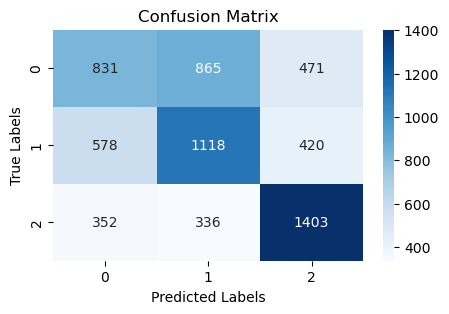

In [67]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_serious)

plt.figure(figsize=(5, 3))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### Accident Severity: Slight/Fatal Injury (1) vs Serious Injury (0)

In [68]:
X_resampled, y_resampled = oversample.fit_resample(X, y_serious)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
nb_model_serious = CategoricalNB()
nb_model_serious.fit(X_train, y_train)

# Create prediction
y_pred_serious = nb_model_serious.predict(X_test)
nb_report(y_test, y_pred_serious)

score_serious = cross_val_score(nb_model_serious, X_test, y_test, cv=5, verbose=1)
cross_scores(score_serious)

Accident_serious
1    7164
0    7164
Name: count, dtype: int64
Accuracy:  0.5796696906257269
Confusion Matrix:
 [[1092 1073]
 [ 734 1400]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.50      0.55      2165
           1       0.57      0.66      0.61      2134

    accuracy                           0.58      4299
   macro avg       0.58      0.58      0.58      4299
weighted avg       0.58      0.58      0.58      4299

Cross-validation scores:  [       nan 0.59767442        nan 0.55930233 0.56111758]
Average score:  nan


c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\model_selection\_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 143, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 455, in __call__
    return estimator.score(*args, **kwargs)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\naive_bayes.py", line 102, in predict
    jll = self._joint_log_likelihood(X)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklea

In [69]:
# Check for missing values
print(np.any(np.isnan(X_train)))
print(np.any(np.isnan(X_test)))

# Check for infinite values
print(np.any(np.isinf(X_train)))
print(np.any(np.isinf(X_test)))

False
False
False
False


In [70]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(nb_model_serious, X_test, y_test, cv=skf)
print(scores)

[       nan 0.59767442        nan 0.55930233 0.56111758]


c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\model_selection\_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 143, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\metrics\_scorer.py", line 455, in __call__
    return estimator.score(*args, **kwargs)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklearn\naive_bayes.py", line 102, in predict
    jll = self._joint_log_likelihood(X)
  File "c:\Users\xxkjx\miniconda3\envs\mambaML\lib\site-packages\sklea

In [44]:
print(multiclass_cm_metrics(cm))

Confusion Matrix:
[[1092 1073]
 [ 734 1400]]
                      Class 0  Class 1
Accuracy              0.57967  0.57967
Error rate            0.42033  0.42033
Sensitivity (Recall)  0.50439  0.65604
Specificity           0.65604  0.50439
Precision             0.59803  0.56611
F1                    0.54723  0.60777
F2                    0.52069  0.63584
F0.5                  0.57662  0.58207


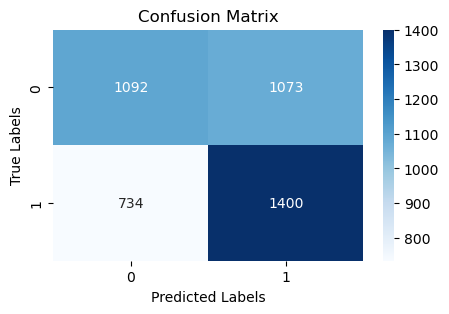

In [42]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_serious)

plt.figure(figsize=(5, 3))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### Analysis of Results

#### Target: Slight Injury (1) vs Serious Injury (0) vs. Fatal Injury (2)

Accuracy: 86%
Precision Serious Injury: 100%
Recall: 1%

##### Resampled

Accuracy: 53%
Precision Serious Injury: 47%
Recall: 38%

#### Target: Slight/Fatal Injury (1) vs Serious Injury (0)

Accuracy: 87%
Precision: 100%
Recall: 1%

##### Resampled

Accuracy: 58%
Precision Serious Injury: 60%
Recall: 50%

A successful model would have 85% accuracy and precision of 90%. 
Unfortunately, these models do not fit the criteria. 



## Modeling Using Random Forest

### Accident Severity: Slight Injury (1) vs. Serious Injury (0) vs. Fatal Injury (2)

In [18]:
# Split model
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.3, 
                                                    random_state=42)

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=84)

# Train
rf_model.fit(X_train, y_train)
# Predict
y_pred = rf_model.predict(X_test)
nb_report(y_test, y_pred)

Accuracy:  0.8501827040194885
Confusion Matrix:
 [[  32  297    1]
 [  46 2062    3]
 [   1   21    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.10      0.16       330
           1       0.87      0.98      0.92      2111
           2       0.00      0.00      0.00        22

    accuracy                           0.85      2463
   macro avg       0.42      0.36      0.36      2463
weighted avg       0.80      0.85      0.81      2463



In [19]:
# Split model / Unmapped
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42)

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=84)

# Train
rf_model.fit(X_train, y_train)
# Predict
y_pred = rf_model.predict(X_test)
nb_report(y_test, y_pred)

Accuracy:  0.8505887129516849
Confusion Matrix:
 [[   1    1   20]
 [   1   32  297]
 [   3   46 2062]]
Classification Report:
                 precision    recall  f1-score   support

  Fatal injury       0.20      0.05      0.07        22
Serious Injury       0.41      0.10      0.16       330
 Slight Injury       0.87      0.98      0.92      2111

      accuracy                           0.85      2463
     macro avg       0.49      0.37      0.38      2463
  weighted avg       0.80      0.85      0.81      2463



### Accident Severity: Slight/Fatal Injury (1) vs Serious Injury (0)

In [20]:
# Split model
X_train, X_test, y_train, y_test = train_test_split(X, y_serious, test_size=0.3, 
                                                    random_state=42)

# Initialize model
rf_model_serious = RandomForestClassifier(n_estimators=100, random_state=84)

# Train
rf_model_serious.fit(X_train, y_train)
# Predict
y_pred = rf_model_serious.predict(X_test)
nb_report(y_test, y_pred)

Accuracy:  0.8587088915956151
Confusion Matrix:
 [[  28  302]
 [  46 2087]]
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.08      0.14       330
           1       0.87      0.98      0.92      2133

    accuracy                           0.86      2463
   macro avg       0.63      0.53      0.53      2463
weighted avg       0.81      0.86      0.82      2463



## Resample Target Data

### Accident Severity: Slight Injury (1) vs. Serious Injury (0) vs. Fatal Injury (2)

In [21]:
oversample = RandomOverSampler(random_state=42)

X_resampled, y_resampled = oversample.fit_resample(X, y_mapped)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
rf_model_rs = RandomForestClassifier()
rf_model_rs.fit(X_train, y_train)

# Create prediction
y_pred_rs = rf_model_rs.predict(X_test)
nb_report(y_test, y_pred_rs)

score_serious = cross_val_score(rf_model_rs, X_test, y_test, cv=5)
cross_scores(score_serious)

cm = confusion_matrix(y_test, y_pred_rs)
multiclass_cm_metrics(cm)

Accident_severity_mapped
1    7082
0    7082
2    7082
Name: count, dtype: int64
Accuracy:  0.9607781612802008
Confusion Matrix:
 [[2128   32    7]
 [ 203 1905    8]
 [   0    0 2091]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95      2167
           1       0.98      0.90      0.94      2116
           2       0.99      1.00      1.00      2091

    accuracy                           0.96      6374
   macro avg       0.96      0.96      0.96      6374
weighted avg       0.96      0.96      0.96      6374

Cross-validation scores:  [0.88470588 0.87137255 0.8745098  0.87607843 0.88540031]
Average score:  0.8784133961276819
Confusion Matrix:
[[2128   32    7]
 [ 203 1905    8]
 [   0    0 2091]]


,Class 0,Class 1,Class 2
Accuracy,0.96203,0.96188,0.99765
Error rate,0.03797,0.03812,0.00235
Sensitivity (Recall),0.98200,0.90028,1.00000
Specificity,0.95175,0.99248,0.99650
Precision,0.91291,0.98348,0.99288
F1,0.94620,0.94004,0.99643
F2,0.96736,0.91578,0.99857
F0.5,0.92594,0.96563,0.99429


### Accident Severity: Slight/Fatal Injury (1) vs Serious Injury (0)

In [22]:
X_resampled, y_resampled = oversample.fit_resample(X, y_serious)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
rf_model_rs = RandomForestClassifier()
rf_model_rs.fit(X_train, y_train)

# Create prediction
y_pred_rs = rf_model_rs.predict(X_test)
nb_report(y_test, y_pred_rs)

score_serious = cross_val_score(rf_model_rs, X_test, y_test, cv=5)
cross_scores(score_serious)

Accident_serious
1    7164
0    7164
Name: count, dtype: int64
Accuracy:  0.9397534310304722
Confusion Matrix:
 [[2131   34]
 [ 225 1909]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      2165
           1       0.98      0.89      0.94      2134

    accuracy                           0.94      4299
   macro avg       0.94      0.94      0.94      4299
weighted avg       0.94      0.94      0.94      4299

Cross-validation scores:  [0.81860465 0.83604651 0.84883721 0.82325581 0.81490105]
Average score:  0.828329046755286


In [23]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y_mapped)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
rf_model_rs = RandomForestClassifier()
rf_model_rs.fit(X_train, y_train)

# Create prediction
y_pred_rs = rf_model_rs.predict(X_test)
nb_report(y_test, y_pred_rs)

score_serious = cross_val_score(rf_model_rs, X_test, y_test, cv=5)
cross_scores(score_serious)

Accident_severity_mapped
1    7082
0    7082
2    7082
Name: count, dtype: int64
Accuracy:  0.8845309068089112
Confusion Matrix:
 [[1853  236   78]
 [ 371 1716   29]
 [  12   10 2069]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      2167
           1       0.87      0.81      0.84      2116
           2       0.95      0.99      0.97      2091

    accuracy                           0.88      6374
   macro avg       0.88      0.89      0.88      6374
weighted avg       0.88      0.88      0.88      6374

Cross-validation scores:  [0.83137255 0.83686275 0.83137255 0.81960784 0.83045526]
Average score:  0.8299341890602395


In [24]:
rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(X, y_mapped)
# Check distribution
print(y_resampled.value_counts())

# Split testing data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42)
# Train model
rf_model_rs = RandomForestClassifier()
rf_model_rs.fit(X_train, y_train)

# Create prediction
y_pred_rs = rf_model_rs.predict(X_test)
nb_report(y_test, y_pred_rs)

score_serious = cross_val_score(rf_model_rs, X_test, y_test, cv=5)
cross_scores(score_serious)

Accident_severity_mapped
0    82
1    82
2    82
Name: count, dtype: int64
Accuracy:  0.4864864864864865
Confusion Matrix:
 [[10 10  2]
 [ 8 13  3]
 [ 9  6 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.45      0.41        22
           1       0.45      0.54      0.49        24
           2       0.72      0.46      0.57        28

    accuracy                           0.49        74
   macro avg       0.51      0.49      0.49        74
weighted avg       0.53      0.49      0.49        74

Cross-validation scores:  [0.46666667 0.4        0.4        0.6        0.42857143]
Average score:  0.45904761904761904


## Conclusion

Our target for a successful model is >=85% accuracy and >=90% precision for the target classification of "Serious Injury". Neither model was able to acheive this requirement due to the class imbalance amongst "Slight injury", "Serious injury", and "Fatal injury". Therefore, resampling was performed. Modeling was performed on the resampled data and "Random Forest Classifier" was able to achieve our success criteria.  